<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 186.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 171.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 168.7 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-03-07 11:46:27--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  41.0MB/s    in 3.7s    

2026-03-07 11:46:31 (41.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


null values before cleaning

 Age               0
SOPartFreq    20200
JobSat        36311
dtype: int64



null values after cleaning

 Age           0
SOPartFreq    0
JobSat        0
dtype: int64


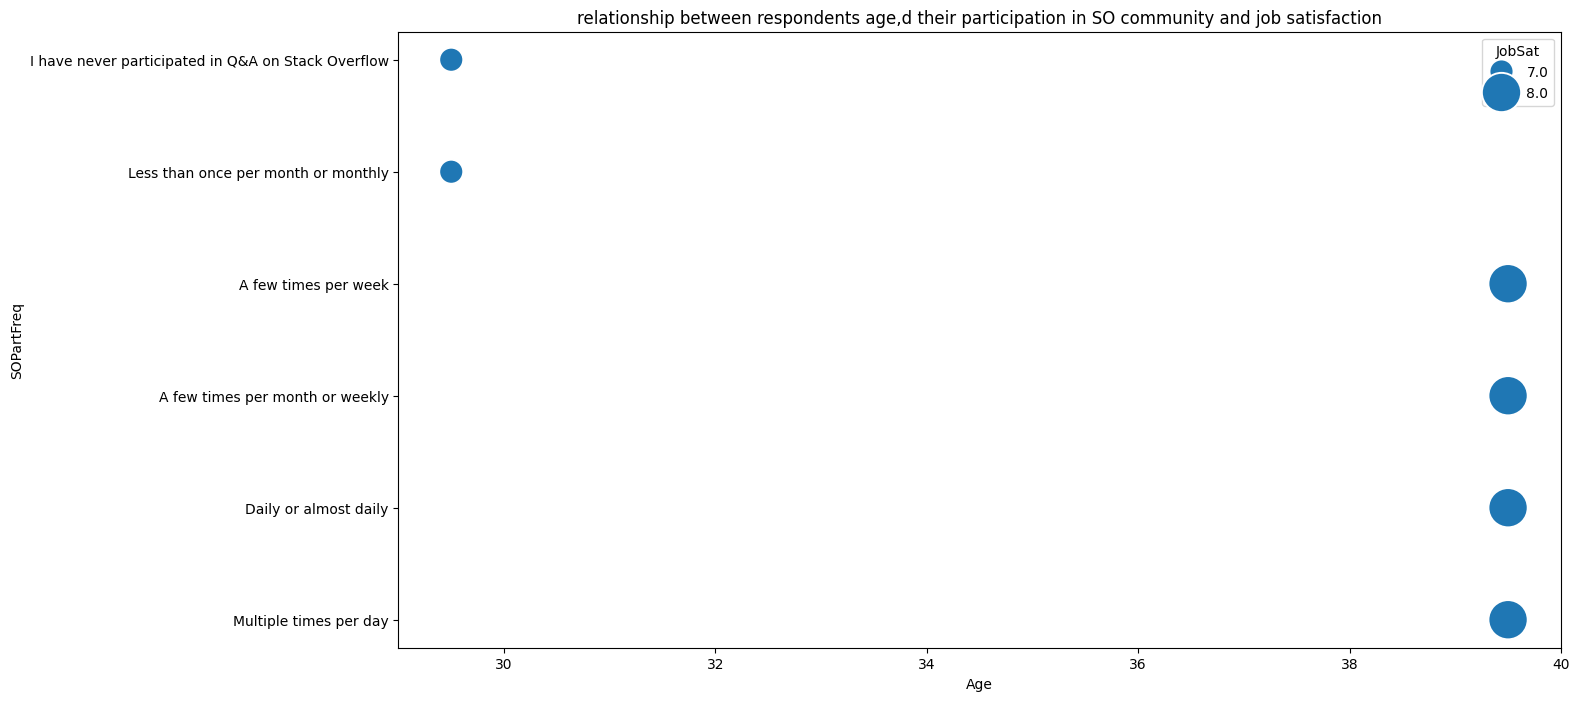

In [3]:
##Write your code here

SO_age=df.copy()

print('null values before cleaning\n\n',SO_age[['Age','SOPartFreq','JobSat']].isnull().sum())
SO_age=SO_age.dropna(subset=['Age','SOPartFreq','JobSat'])
print('\n\n\nnull values after cleaning\n\n',SO_age[['Age','SOPartFreq','JobSat']].isnull().sum())

SO_age=SO_age[SO_age['Age']!='Prefer not to say']

SO_age['Age']=SO_age['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

SO_age['Age']=pd.to_numeric(SO_age['Age'],errors='coerce')
SO_age = SO_age.dropna(subset=['Age'])

grouped_SO_age=(
    SO_age.groupby('SOPartFreq')[['JobSat','Age']].median()
    .sort_values('JobSat').reset_index()
)

plt.figure(figsize=(15,8))
sns.scatterplot(
    data=grouped_SO_age
    ,x='Age'
    ,y='SOPartFreq'
    ,size=grouped_SO_age['JobSat']
    ,sizes=(300,800)
)
plt.title('relationship between respondents age,d their participation in SO community and job satisfaction')
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [4]:
##Write your code here

comp_sat=df.copy()

print('null values before cleaning\n\n',comp_sat[['JobSat','ConvertedCompYearly']].isnull().sum())
comp_sat=comp_sat.dropna(subset=['JobSat','ConvertedCompYearly'])
print('\n\n\nnull values after cleaning\n\n',comp_sat[['JobSat','ConvertedCompYearly']].isnull().sum())

comp_sat=comp_sat[comp_sat['Age']!='Prefer not to say']

Q1=np.quantile(comp_sat['ConvertedCompYearly'], 0.25)
Q3=np.quantile(comp_sat['ConvertedCompYearly'], 0.75)
IQR=Q3-Q1

print('\ncompensation skewness before limiting data',comp_sat['ConvertedCompYearly'].skew())

max_value=Q3+3*IQR                                               # IQR multiplication raised to 3 because compensation data is usually strongly right skewed
min_value=Q1-1.5*IQR

comp_sat=comp_sat[
                    (comp_sat['ConvertedCompYearly']>min_value)  # Extreme compensation values were removed using the IQR method to improve visualization clarity
                    & (comp_sat['ConvertedCompYearly']<max_value)
]

print('\ncompensation skewness after limiting data',comp_sat['ConvertedCompYearly'].skew())

comp_sat['Age']=comp_sat['Age'].replace({                         # Age ranges were converted to approximate numeric midpoints to allow quantitative analysis and bubble size representation
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

comp_sat['Age']=pd.to_numeric(comp_sat['Age'],errors='coerce')
comp_sat = comp_sat.dropna(subset=['Age'])

null values before cleaning

 JobSat                 36311
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSat                 0
ConvertedCompYearly    0
dtype: int64

compensation skewness before limiting data 46.067066869993106

compensation skewness after limiting data 1.138391698340501


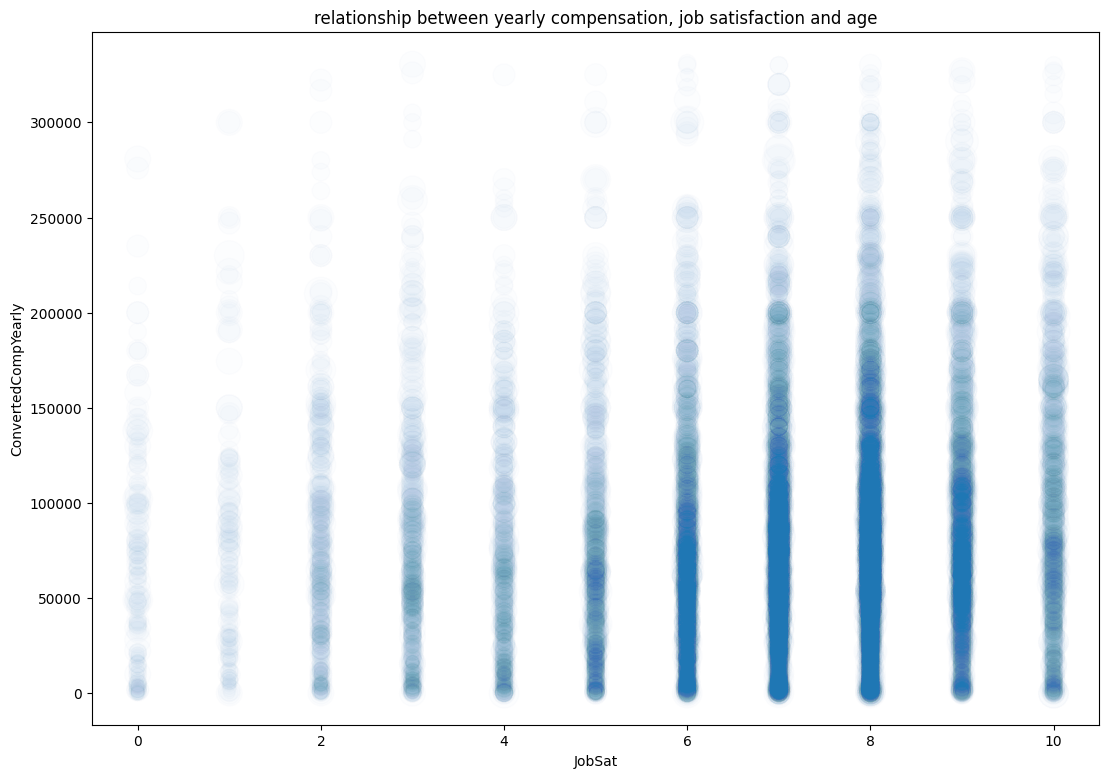

In [5]:
comp_sat.plot(
    kind='scatter'
    ,x='JobSat'
    ,y='ConvertedCompYearly'
    ,s=comp_sat['Age']**1.5
    ,alpha=0.01
    ,figsize=(13,9)
    ,title='relationship between yearly compensation, job satisfaction and age'
)
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [6]:
##Write your code here

age_technology=df.copy()

print('null values before cleaning',age_technology['LanguageHaveWorkedWith'].isnull().sum())
age_technology=age_technology.dropna(subset=['LanguageHaveWorkedWith'])
print('\n\nnull values after cleaning',age_technology['LanguageHaveWorkedWith'].isnull().sum())

age_technology=age_technology[age_technology['Age']!='Prefer not to say']

age_technology['language']=age_technology['LanguageHaveWorkedWith'].str.split(';')
age_technology=age_technology.explode('language')                                            # Split multi-language responses and convert them into separate rows so each language can be analyzed individually

top12=(                                                                            # Keep only the 12 most frequently used coding languages to improve readability
    age_technology.groupby('language').size()
    .sort_values(ascending=False).head(12).index
)

age_technology=age_technology[age_technology['language'].isin(top12)]

age_technology['Age']=age_technology['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_technology['Age']=pd.to_numeric(age_technology['Age'],errors='coerce')
age_technology = age_technology.dropna(subset=['Age'])

grouped_age_technology=(age_technology.groupby(['language','Age']).size()
                        .reset_index(name='size')
                        .sort_values('size',ascending=False)
                       )

null values before cleaning 5692


null values after cleaning 0


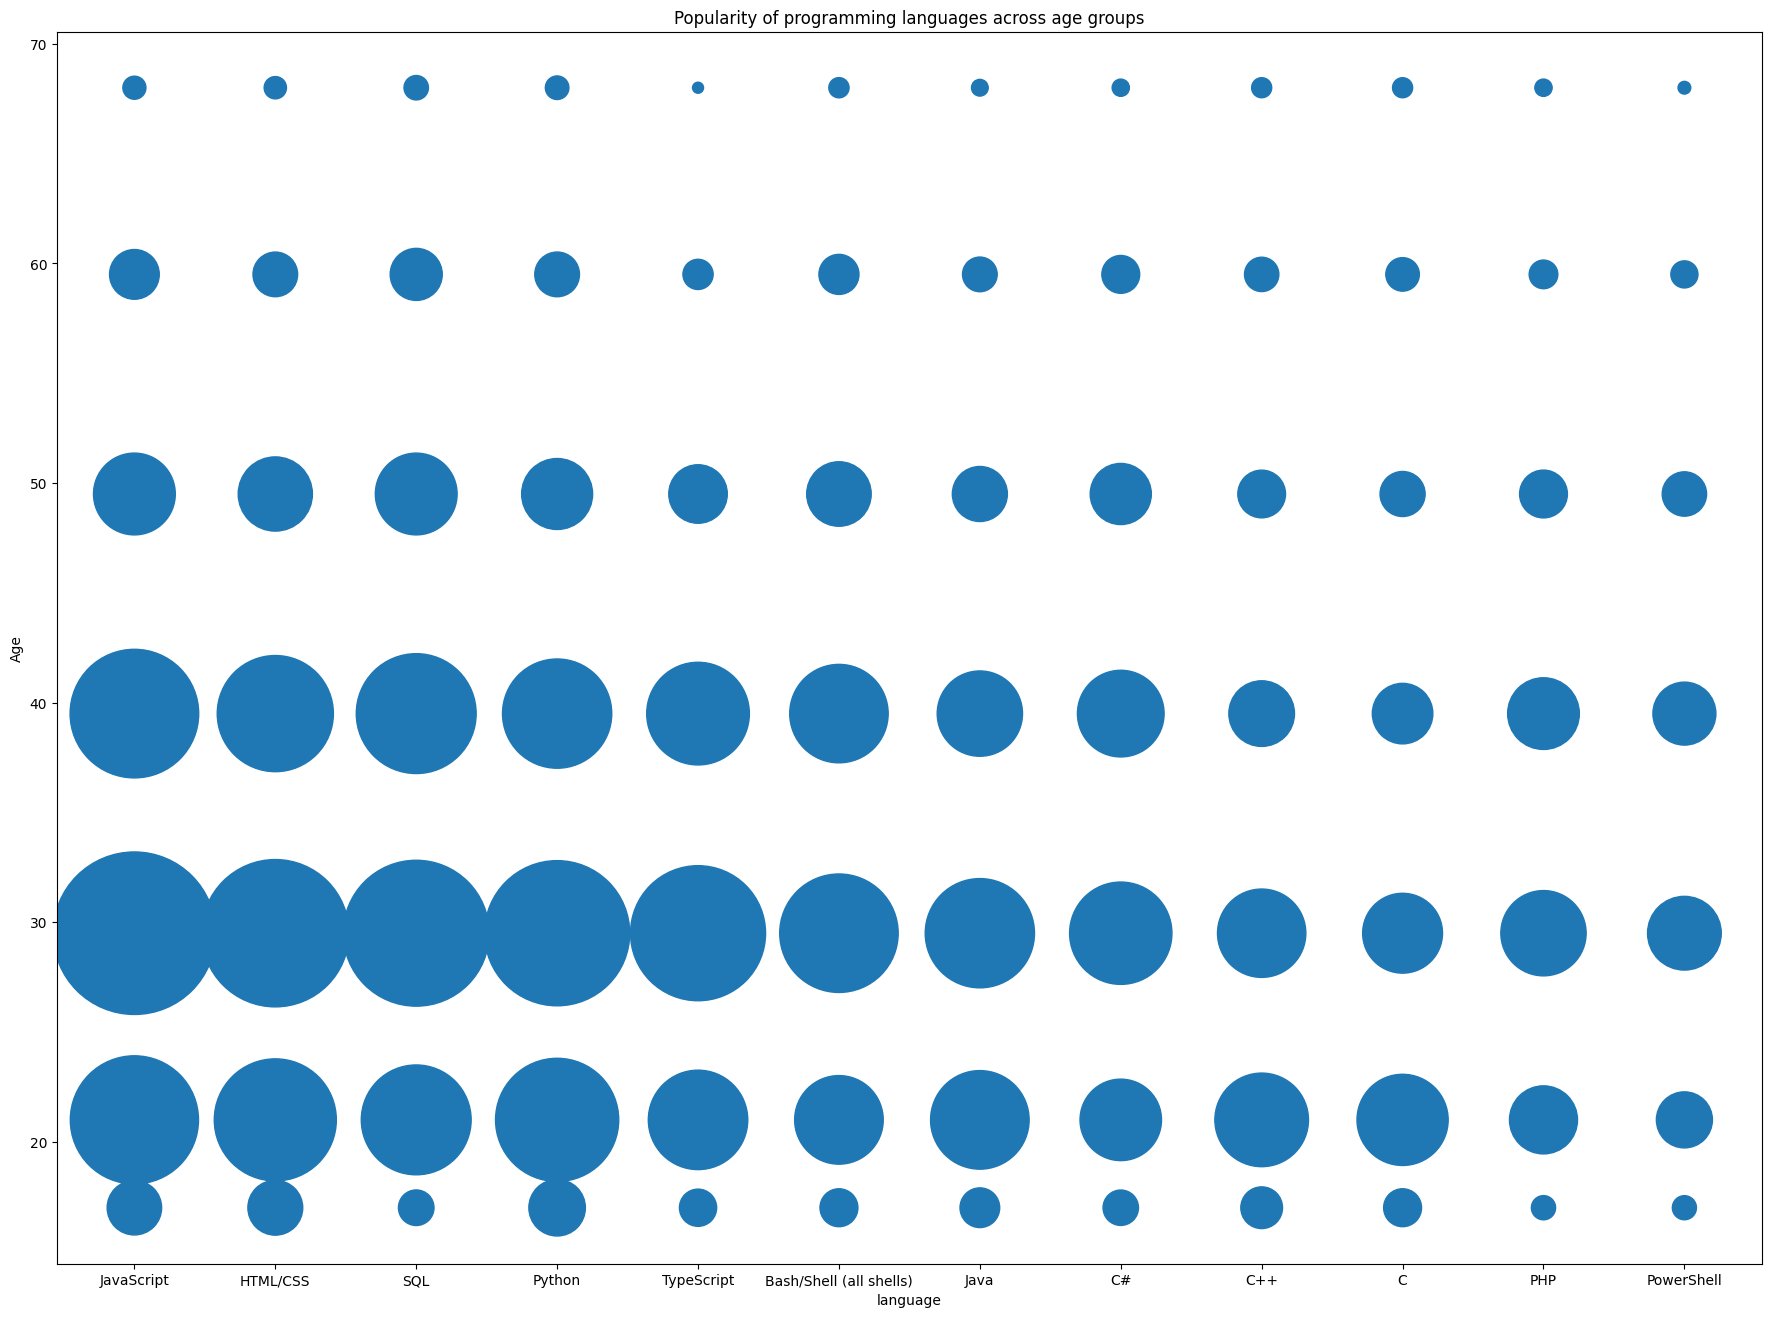

In [21]:
grouped_age_technology.plot(
    kind='scatter'
    ,x='language'
    ,y='Age'
    ,s='size'
    ,figsize=(22,16)
    ,title='Popularity of programming languages across age groups'
)
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [7]:
##Write your code here

dbase_sat=df.copy()

print('null values before cleaning\n\n',dbase_sat[['JobSat','DatabaseWantToWorkWith']].isnull().sum())
dbase_sat=dbase_sat.dropna(subset=['JobSat','DatabaseWantToWorkWith'])
print('\n\n\nnull values after cleaning\n\n',dbase_sat[['JobSat','DatabaseWantToWorkWith']].isnull().sum())

dbase_sat['dbase']=dbase_sat['DatabaseWantToWorkWith'].str.split(';')
dbase_sat=dbase_sat.explode('dbase')                                                                                # Split responses containing multiple databases into separate rows so each database can be analyzed individually

top12db=(                                                        # Keep only the 12 most frequently used databases to improve readability
    dbase_sat.groupby('dbase').size()
    .sort_values(ascending=False).head(12).index
)

dbase_sat=dbase_sat[dbase_sat['dbase'].isin(top12db)]

grouped_db_sat=(dbase_sat.groupby(['dbase','JobSat']).size()
                .reset_index(name='size')
                .sort_values('size',ascending=False)
               )

null values before cleaning

 JobSat                    36311
DatabaseWantToWorkWith    22879
dtype: int64



null values after cleaning

 JobSat                    0
DatabaseWantToWorkWith    0
dtype: int64


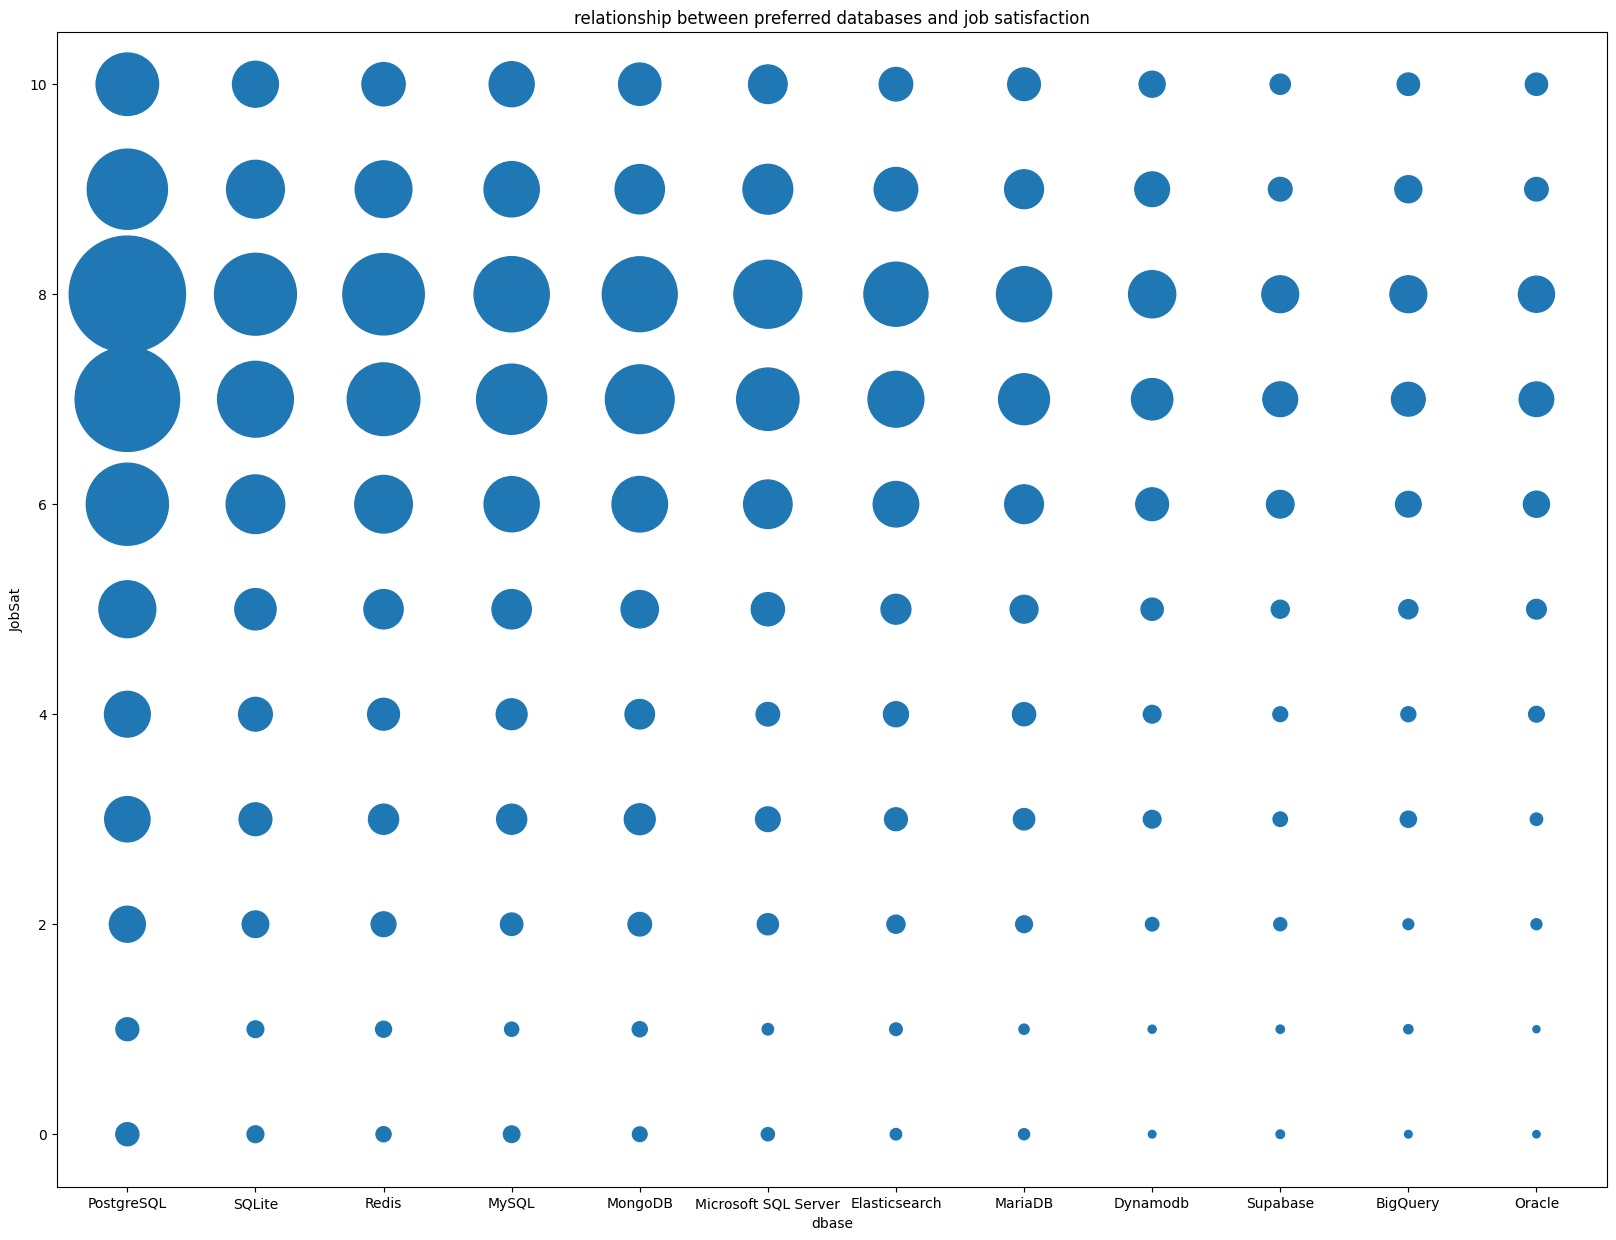

In [8]:
grouped_db_sat.plot(
    kind='scatter'
    ,x='dbase'
    ,y='JobSat'
    ,s=grouped_db_sat['size']*2
    ,figsize=(20,15)
    ,title='relationship between preferred databases and job satisfaction'
)
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [9]:
##Write your code here

dev_comp=df.copy()

print('null values before cleaning\n\n',dev_comp[['JobSat','DevType','ConvertedCompYearly']].isnull().sum())
dev_comp=dev_comp.dropna(subset=['JobSat','DevType','ConvertedCompYearly'])
print('\n\n\nnull values after cleaning\n\n',dev_comp[['JobSat','DevType','ConvertedCompYearly']].isnull().sum())

top10dev=(                                                                 # Keep only the 10 most frequent Developer types to improve readability
    dev_comp.groupby('DevType').size()
    .sort_values(ascending=False).head(10).index
)

dev_comp=dev_comp[dev_comp['DevType'].isin(top10dev)]

dev_grouped=(
    dev_comp.groupby('DevType')[['JobSat','ConvertedCompYearly']].median()
    .reset_index()
    .sort_values('ConvertedCompYearly')
)

null values before cleaning

 JobSat                 36311
DevType                 5992
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSat                 0
DevType                0
ConvertedCompYearly    0
dtype: int64


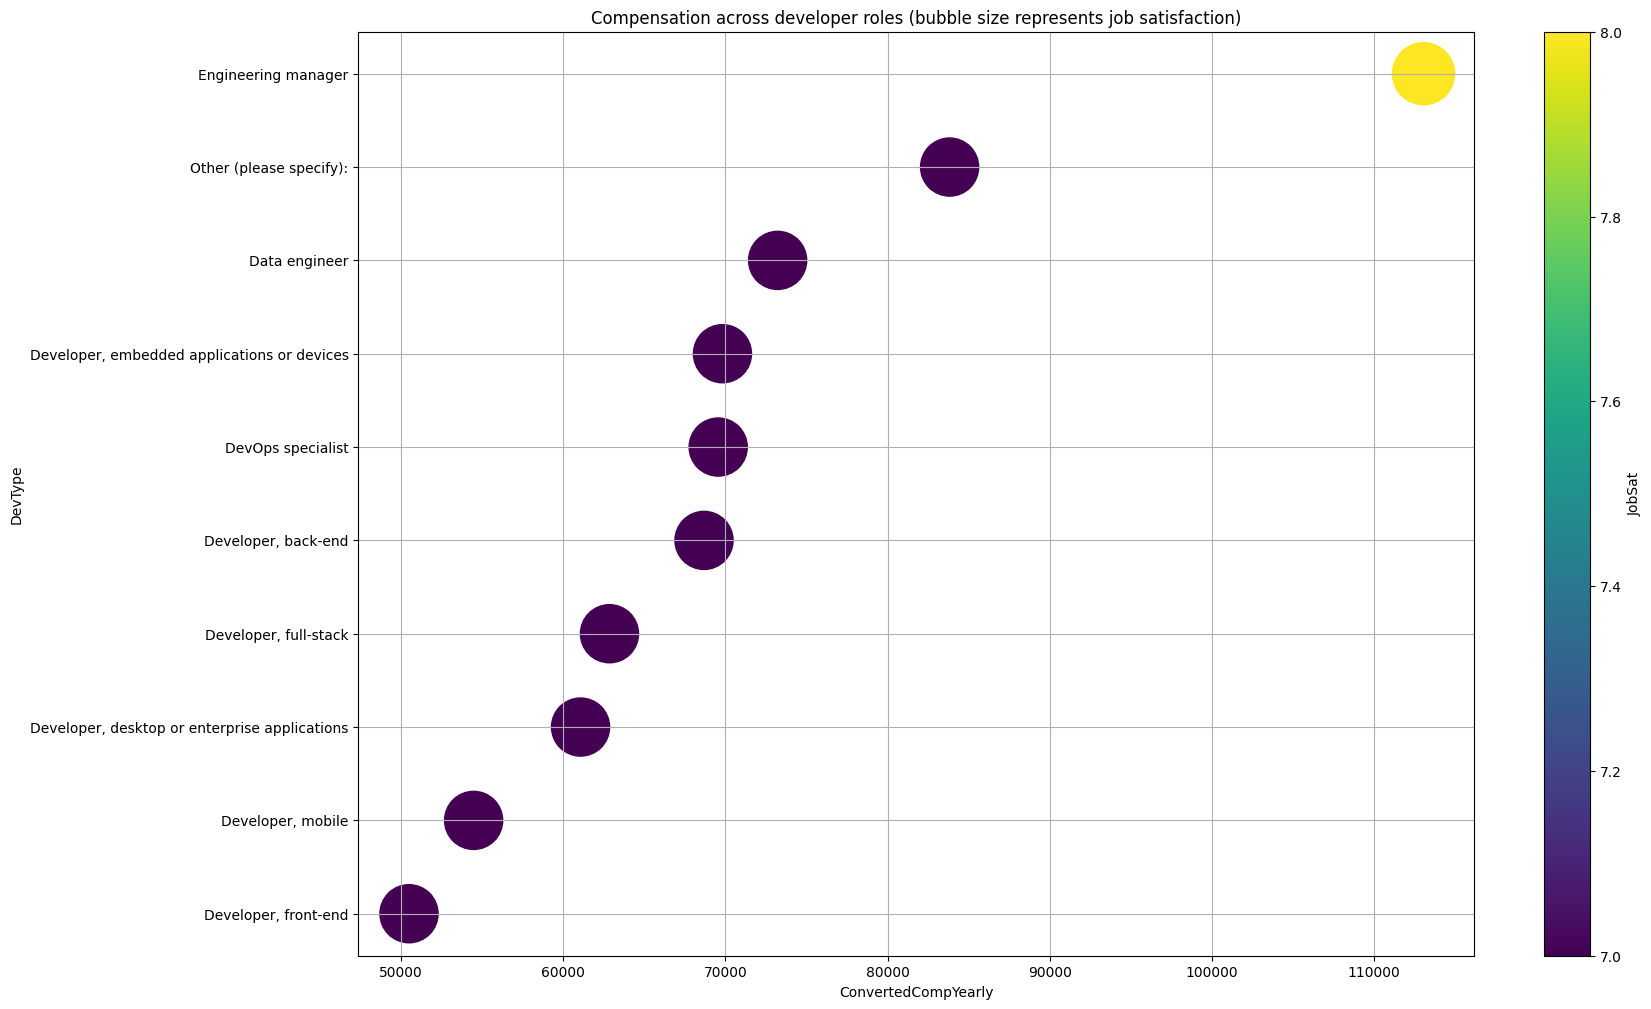

In [10]:
dev_grouped.plot(
    kind='scatter'
    ,x='ConvertedCompYearly'
    ,y='DevType'
    ,s=dev_grouped['JobSat']*250
    ,c='JobSat'
    ,figsize=(18,12)
    ,grid=True
    ,title='Compensation across developer roles (bubble size represents job satisfaction)'
)
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [11]:
##Write your code here

tool_age=df.copy()

print('null values before cleaning',tool_age['NEWCollabToolsHaveWorkedWith'].isnull().sum())
tool_age=tool_age.dropna(subset=['NEWCollabToolsHaveWorkedWith'])
print('\n\nnull values after cleaning',tool_age['NEWCollabToolsHaveWorkedWith'].isnull().sum())

tool_age=tool_age[tool_age['Age']!='Prefer not to say']

tool_age['Age']=tool_age['Age'].replace({                                     # Convert age groups to numeric values to enable plotting
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

tool_age['Age']=pd.to_numeric(tool_age['Age'],errors='coerce')
tool_age = tool_age.dropna(subset=['Age'])

tool_age['tool']=tool_age['NEWCollabToolsHaveWorkedWith'].str.split(';')
tool_age=tool_age.explode('tool')                                                 # Respondents may report multiple tools; split them into separate rows

top10tools=(
    tool_age.groupby('tool').size()                                              # Keep only the 10 most frequently used collaboration tools to improve readability
    .sort_values(ascending=False).head(10).index
)

tool_age=tool_age[tool_age['tool'].isin(top10tools)]

grouped_age_tool=(tool_age.groupby(['tool','Age']).size()
                .reset_index(name='size').sort_values('size',ascending=False)
               )

null values before cleaning 7845


null values after cleaning 0


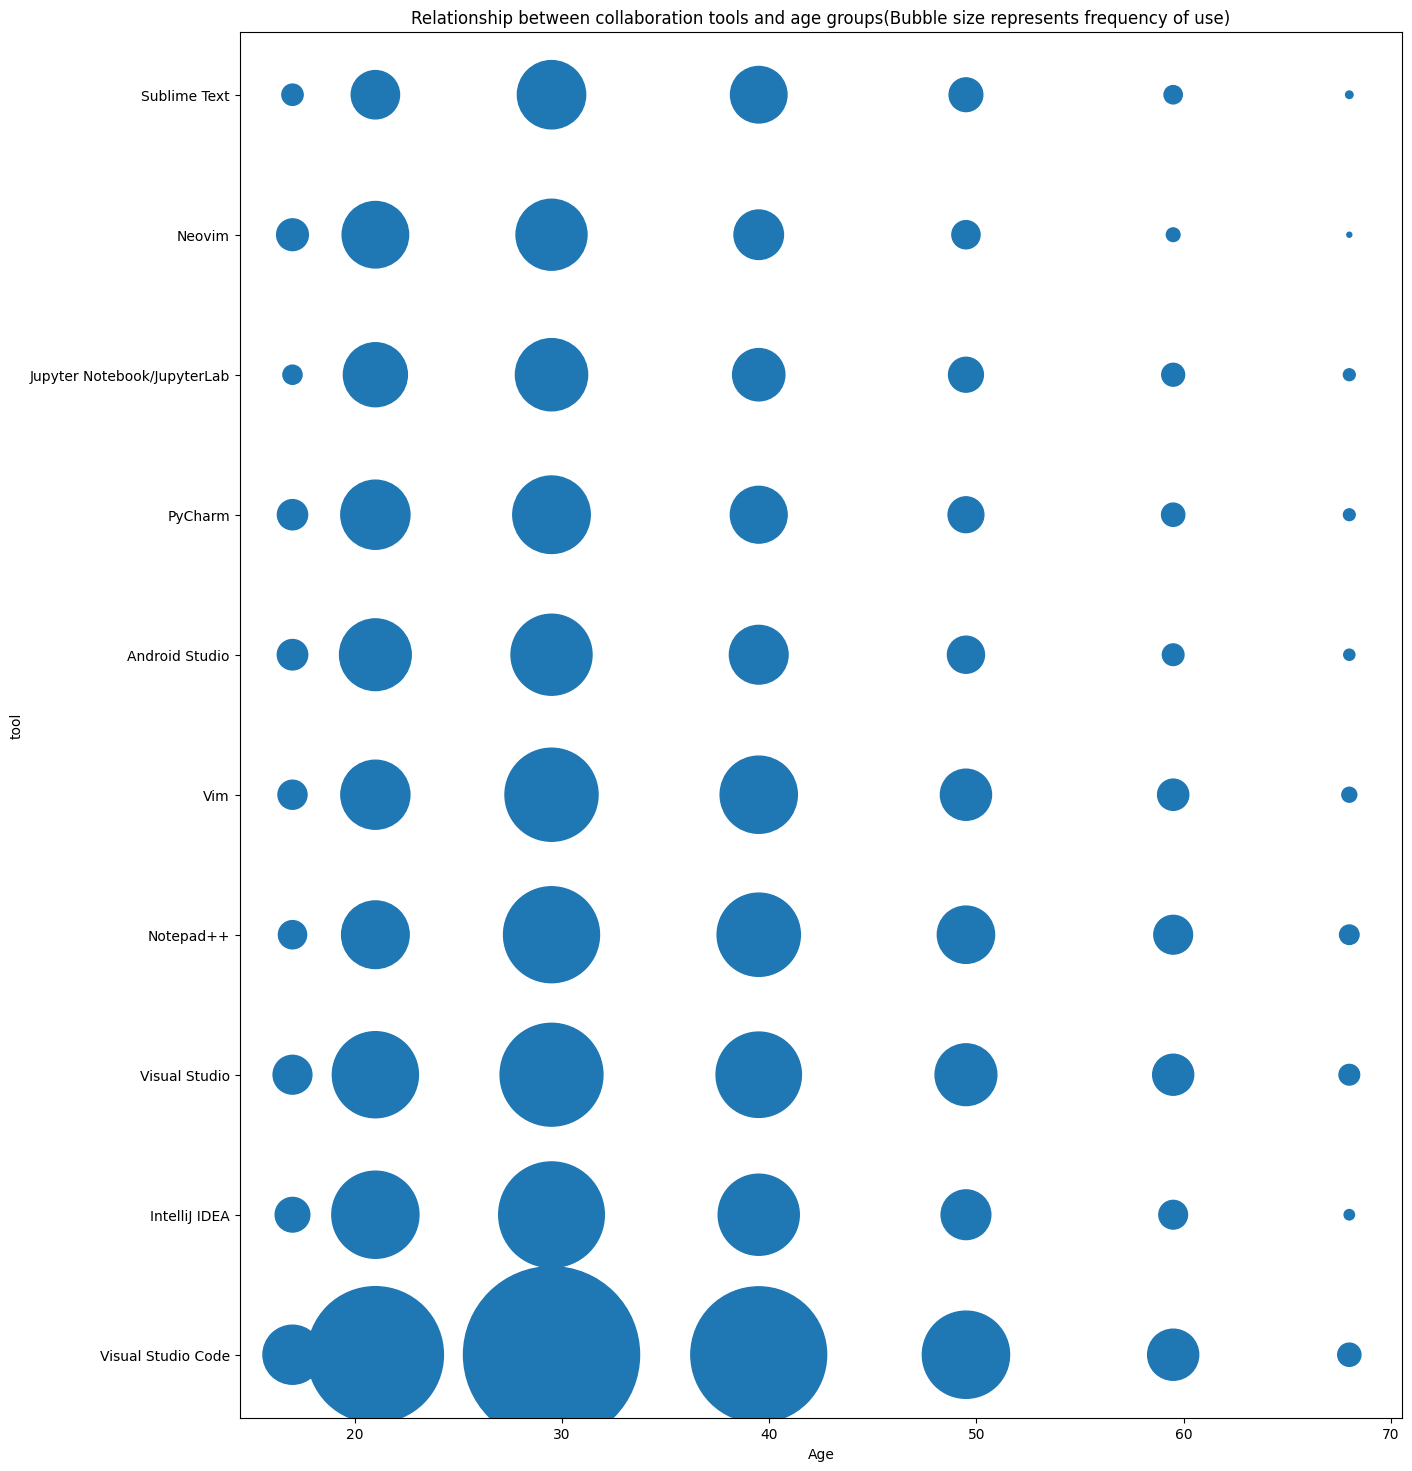

In [12]:
grouped_age_tool.plot(
    kind='scatter'
    ,x='Age'
    ,y='tool'
    ,s='size'
    ,figsize=(15,18)
    ,title='Relationship between collaboration tools and age groups(Bubble size represents frequency of use)'
)
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [13]:
##Write your code here

wframe_sat=df.copy()

print('null values before cleaning\n\n',wframe_sat[['JobSat','WebframeWantToWorkWith']].isnull().sum())
wframe_sat=wframe_sat.dropna(subset=['JobSat','WebframeWantToWorkWith'], axis=0)
print('\n\n\nnull values after cleaning\n\n',wframe_sat[['JobSat','WebframeWantToWorkWith']].isnull().sum())

wframe_sat['wframe']=wframe_sat['WebframeWantToWorkWith'].str.split(';')
wframe_sat=wframe_sat.explode('wframe')                                                   # split multiple frameworks and create one row per framework

top12frames=(
    wframe_sat.groupby('wframe').size()                                                  # keep only the 12 most common frameworks to avoid overcrowded plot
    .sort_values(ascending=False).head(12).index
)

wframe_sat=wframe_sat[wframe_sat['wframe'].isin(top12frames)]

grouped_wframe_sat=(wframe_sat.groupby(['wframe','JobSat']).size()
                .reset_index(name='size')
                .sort_values('size',ascending=False)
               )

null values before cleaning

 JobSat                    36311
WebframeWantToWorkWith    26902
dtype: int64



null values after cleaning

 JobSat                    0
WebframeWantToWorkWith    0
dtype: int64


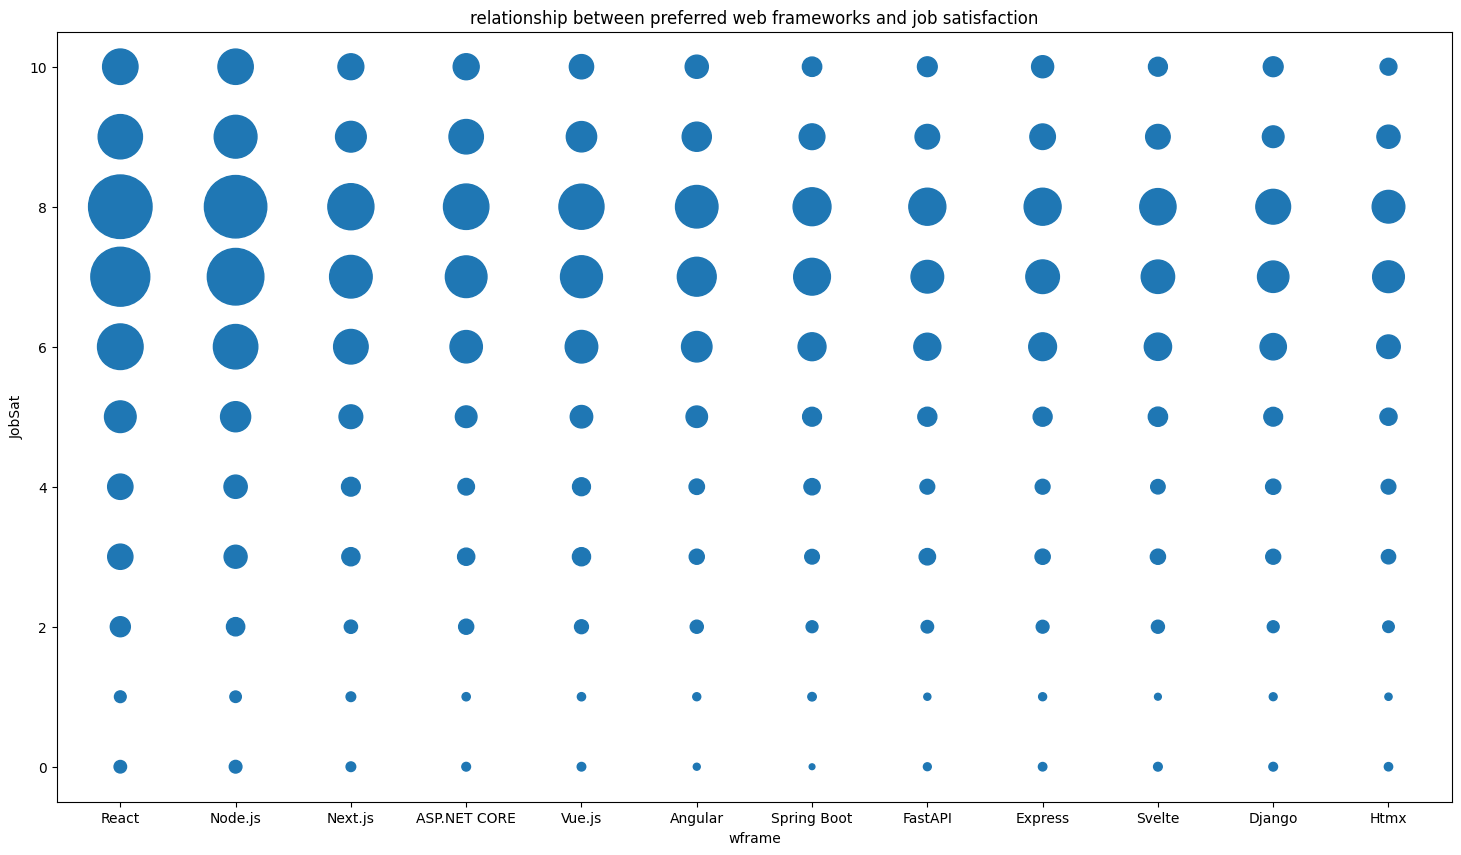

In [14]:
grouped_wframe_sat.plot(
    kind='scatter'
    ,x='wframe'
    ,y='JobSat'
    ,s='size'
    ,figsize=(18,10)
    ,title='relationship between preferred web frameworks and job satisfaction'
)
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [18]:
##Write your code here

country_admire=df.copy()

print('null values before cleaning\n\n',country_admire[['Country','LanguageAdmired']].isnull().sum())
country_admire=country_admire.dropna(subset=['Country','LanguageAdmired'])
print('\n\n\nnull values after cleaning\n\n',country_admire[['Country','LanguageAdmired']].isnull().sum())

top12countries=(                                       # keep only the 12 countries with the most respondents to avoid overcrowded plot
    country_admire.groupby('Country').size()
    .sort_values(ascending=False).head(12).index
)

country_admire=country_admire[country_admire['Country'].isin(top12countries)]

country_admire['Country']=country_admire['Country'].replace('United Kingdom of Great Britain and Northern Ireland','UK')

country_admire['admired']=country_admire['LanguageAdmired'].str.split(';')
country_admire=country_admire.explode('admired')                                   # split multiple languages and create one row per language

top12lang=(
    country_admire.groupby('admired').size()
    .sort_values(ascending=False).head(12).index                                   # keep the 12 most admired programming languages to avoid overcrowded plot
)

country_admire=country_admire[country_admire['admired'].isin(top12lang)]

grouped_country_admire=(country_admire.groupby(['Country','admired']).size()
                        .reset_index(name='size')
                        .sort_values('size', ascending=False)
                       )

null values before cleaning

 Country             6507
LanguageAdmired    14565
dtype: int64



null values after cleaning

 Country            0
LanguageAdmired    0
dtype: int64


,Country,admired,size
140,United States of America,Python,4190
142,United States of America,SQL,3765
139,United States of America,JavaScript,3728
137,United States of America,HTML/CSS,3513
132,United States of America,Bash/Shell (all shells),2872
...,...,...,...
15,Brazil,C++,106
13,Brazil,C,102
121,Ukraine,C,101
76,Italy,Go,99


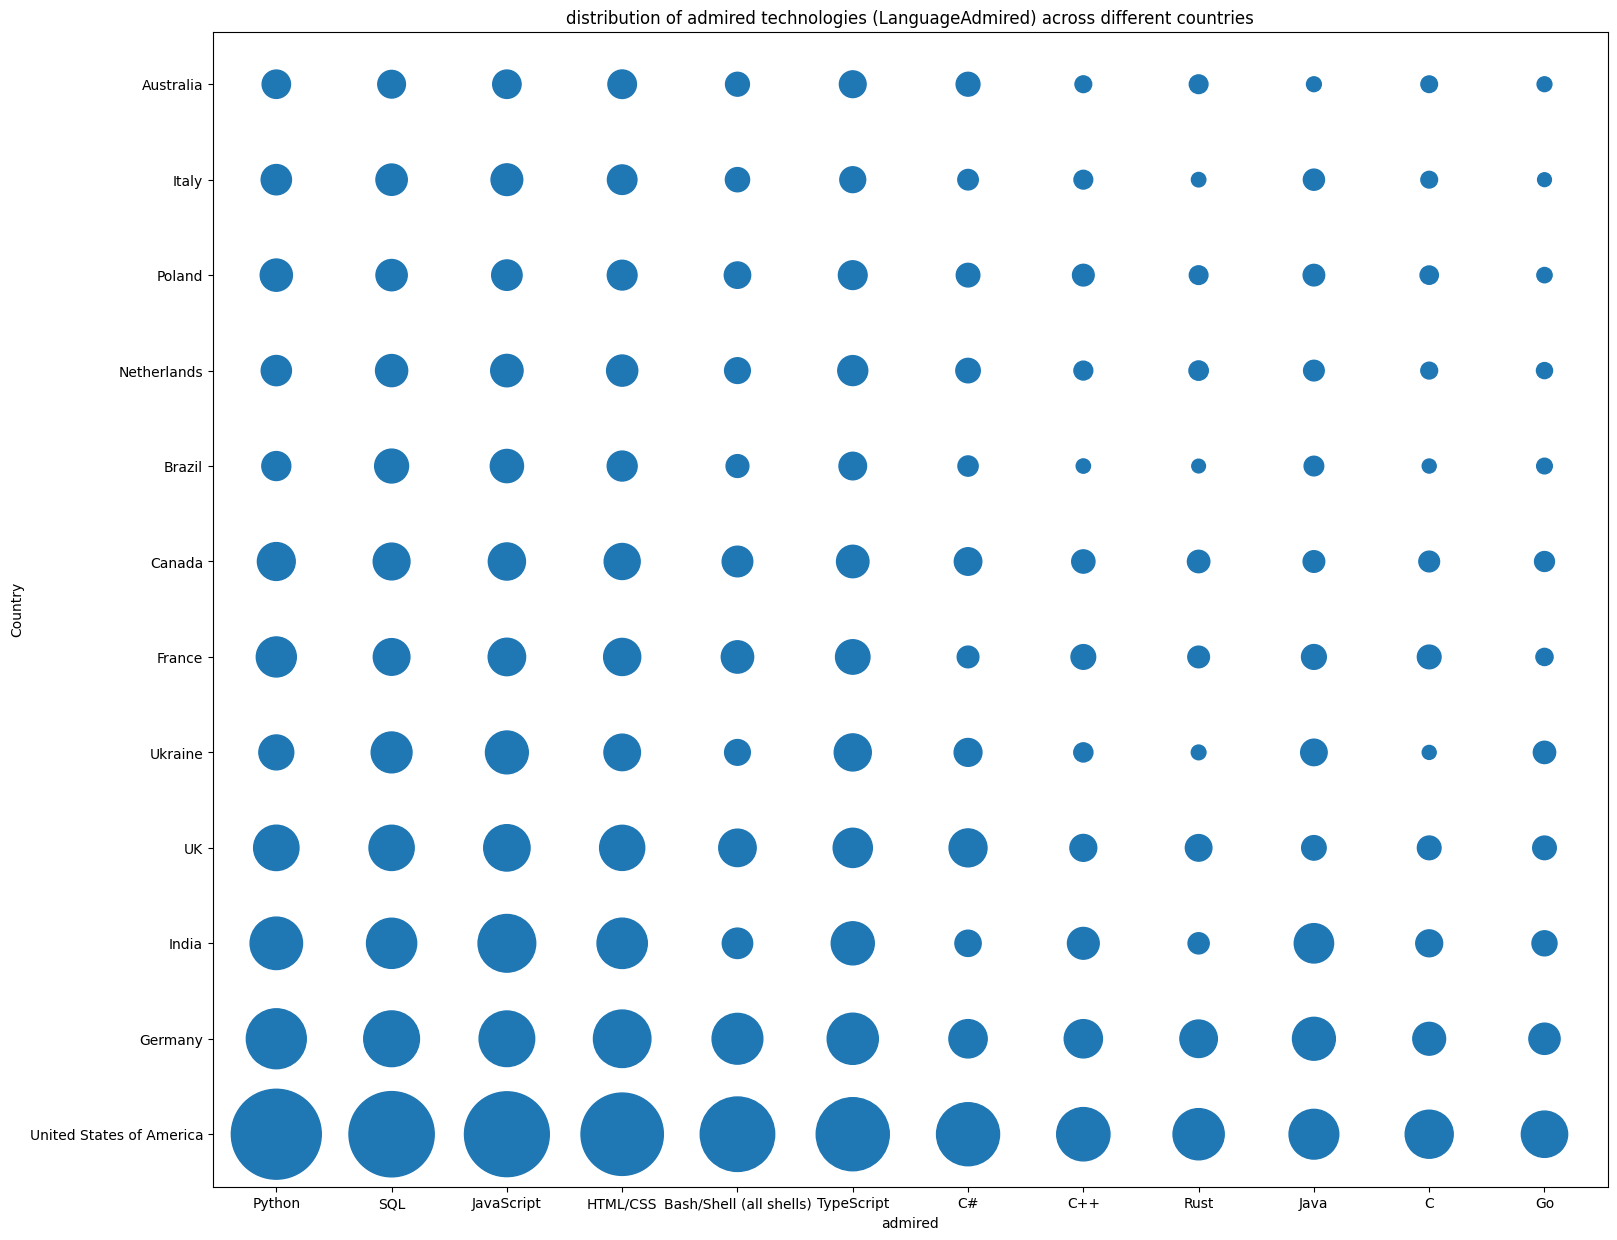

In [19]:
grouped_country_admire.plot(
    kind='scatter'
    ,x='admired'
    ,y='Country'
    ,s='size'
    ,figsize=(18,15)
    ,title='distribution of admired technologies (LanguageAdmired) across different countries'
)
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
